<a href="https://colab.research.google.com/github/CodeWithSudhanshu/Industrial-Plume-Detection/blob/main/PCI_Plume_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

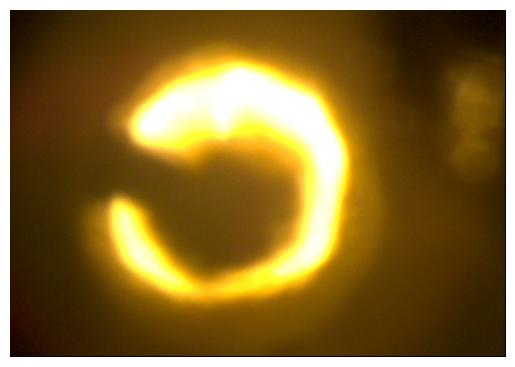

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img1.jpeg")

# convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [ ]:
print(img.shape)             # image height , image width , color channels

(350, 500, 3)


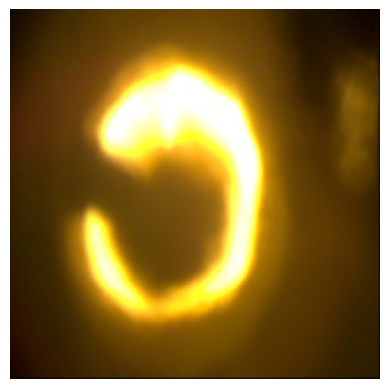

In [ ]:
img_resized = cv2.resize(img_rgb, (256, 256))

plt.imshow(img_resized)         #resizing bcz deep learning models use fixed sizing
plt.axis("off")                 # 128 x 128 , 256 x 256 , 512 x 512
plt.show()

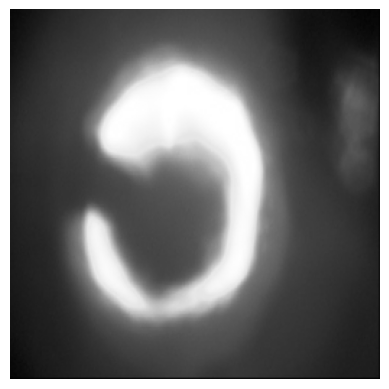

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img1.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (256, 256))

gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)   # convert to grayscale

plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()

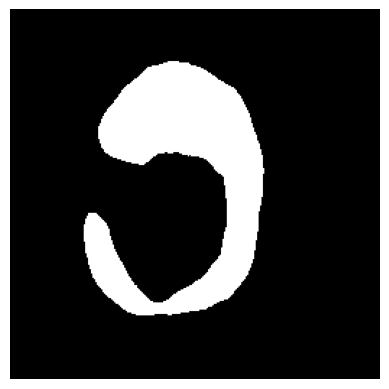

In [ ]:
_, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.axis("off")
plt.show()

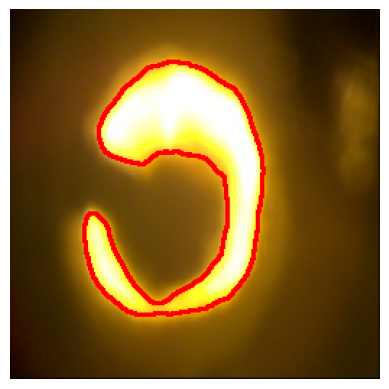

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img1.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (256, 256))
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

_, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contour_img = img_resized.copy()   #drawing contour

cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 2)

plt.imshow(contour_img)
plt.axis("off")
plt.show()



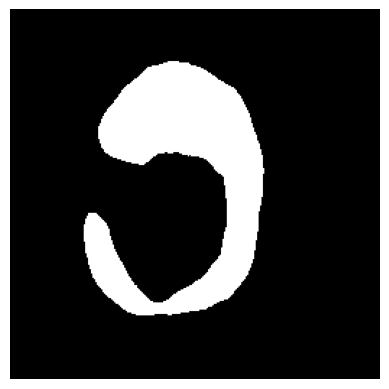

In [ ]:
import numpy as np

mask = np.zeros(gray.shape, dtype=np.uint8)    #creating empty black img..

cv2.drawContours(mask, contours, -1, 255, thickness=cv2.FILLED)  #filling contour with white clrr

plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
import os

print(os.listdir())

['.config', 'img15.jpeg', 'img1.jpeg', 'img2.jpeg', 'img5.jpeg', 'img10.jpeg', 'img7.jpeg', 'img12.jpeg', 'img14.jpeg', 'img8.jpeg', 'img4.jpeg', 'img9.jpeg', 'img3.jpeg', 'img13.jpeg', 'img11.jpeg', 'img6.jpeg', 'sample_data']


In [ ]:
import os

os.makedirs("masks", exist_ok=True)

print("Masks folder is now created")

Masks folder is now created


In [ ]:
import cv2
import os
import numpy as np

for file in os.listdir():

    if file.endswith(".jpeg"):

        img = cv2.imread(file)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (256, 256))
        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

        _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)   #thresholding

        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        mask = np.zeros(gray.shape, dtype=np.uint8)

        cv2.drawContours(    #filling the colours
            mask,
            contours,
            -1,
            255,
            thickness=cv2.FILLED
        )

        save_path = os.path.join("masks", file)  #saving images as mask image
        cv2.imwrite(save_path, mask)
        print(f"Processed: {file}")

Processed: img15.jpeg
Processed: img1.jpeg
Processed: img2.jpeg
Processed: img5.jpeg
Processed: img10.jpeg
Processed: img7.jpeg
Processed: img12.jpeg
Processed: img14.jpeg
Processed: img8.jpeg
Processed: img4.jpeg
Processed: img9.jpeg
Processed: img3.jpeg
Processed: img13.jpeg
Processed: img11.jpeg
Processed: img6.jpeg


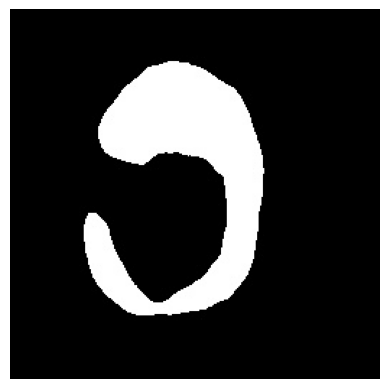

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

mask_path = "masks/img1.jpeg"

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
import os

print(os.listdir("masks"))

['img15.jpeg', 'img1.jpeg', 'img2.jpeg', 'img5.jpeg', 'img10.jpeg', 'img7.jpeg', 'img12.jpeg', 'img14.jpeg', 'img8.jpeg', 'img4.jpeg', 'img9.jpeg', 'img3.jpeg', 'img13.jpeg', 'img11.jpeg', 'img6.jpeg']


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/PCI-PROJECT"

folders = [
    "images",
    "masks",
    "annotations",
    "notebooks",
    "models"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)
print("This creates the project folder.")

This creates the project folder.


In [ ]:
image_path = "/content/drive/MyDrive/PCI-PROJECT/images/PCI images"

print(os.listdir(image_path))

['img13.jpeg', 'img15.jpeg', 'img10.jpeg', 'img3.jpeg', 'img8.jpeg', 'img12.jpeg', 'img7.jpeg', 'img6.jpeg', 'img4.jpeg', 'img2.jpeg', 'img11.jpeg', 'img9.jpeg', 'img5.jpeg', 'img1.jpeg', 'img14.jpeg']


In [ ]:
import cv2
import os
import numpy as np

image_path = "/content/drive/MyDrive/PCI-PROJECT/images/PCI images"

mask_path = "/content/drive/MyDrive/PCI-PROJECT/masks"

for file in os.listdir(image_path):

    if file.endswith(".jpeg"):

        img_full_path = os.path.join(image_path, file)

        img = cv2.imread(img_full_path)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_resized = cv2.resize(img_rgb, (256, 256))   #resizing is always important

        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

        _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        mask = np.zeros(gray.shape, dtype=np.uint8)

        cv2.drawContours(
            mask,
            contours,
            -1,
            255,
            thickness=cv2.FILLED
        )

        save_path = os.path.join(mask_path, file)

        cv2.imwrite(save_path, mask)

        print(f"Processed: {file}")

Processed: img13.jpeg
Processed: img15.jpeg
Processed: img10.jpeg
Processed: img3.jpeg
Processed: img8.jpeg
Processed: img12.jpeg
Processed: img7.jpeg
Processed: img6.jpeg
Processed: img4.jpeg
Processed: img2.jpeg
Processed: img11.jpeg
Processed: img9.jpeg
Processed: img5.jpeg
Processed: img1.jpeg
Processed: img14.jpeg


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install labelme

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.7/594.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 995.9/995.9 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


In [ ]:
import os
train_json_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"
print(os.listdir(train_json_path))

['img1.json', 'img2.json', 'img3.json']


In [ ]:
import os
import json
import cv2
import numpy as np

train_json_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"

json_files = [f for f in os.listdir(train_json_path) if f.endswith(".json")]

for file in json_files:

    json_path = os.path.join(train_json_path, file)

    with open(json_path, 'r') as f:
        data = json.load(f)                            # here we are converting polygon annotations into binary masks

    image_height = data['imageHeight']                 # for every .json file polygon coordinates ko we have converted into black-white mask image using OpenCV polygon filling.
    image_width = data['imageWidth']

    mask = np.zeros((image_height, image_width), dtype=np.uint8)

    for shape in data['shapes']:

        points = np.array(shape['points'], dtype=np.int32)

        cv2.fillPoly(mask, [points], 255)

    output_name = file.replace(".json", "_mask.png")

    output_path = os.path.join(train_json_path, output_name)

    cv2.imwrite(output_path, mask)

    print(f"Mask created: {output_name}")

Mask created: img1_mask.png
Mask created: img2_mask.png
Mask created: img3_mask.png


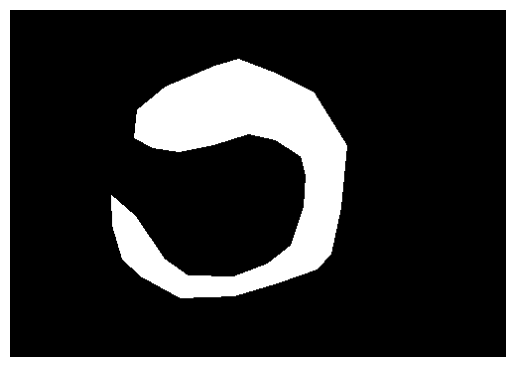

In [ ]:
import matplotlib.pyplot as plt

mask_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks/img1_mask.png"

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
!pip install torch torchvision

In [ ]:
import torch
from torch.utils.data import Dataset      # humne Pytorch install kra bcz it tells the AI model where images,masks are and how to load them . Iske bina our model can't be train !
import cv2
import os

class PlumeDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = os.listdir(image_dir)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(
            self.image_dir,
            self.images[index]
        )

        mask_name = self.images[index].replace(".jpeg", "_mask.png")

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = cv2.imread(img_path)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        return image, mask



In [ ]:
train_dataset = PlumeDataset(   #creating dataset object

    image_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/images",

    mask_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"
)
print(len(train_dataset))

3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset
import cv2
import os

class PlumeDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = [
            file for file in os.listdir(image_dir)
            if file.endswith(".jpeg")
        ]

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(
            self.image_dir,
            self.images[index]
        )

        mask_name = self.images[index].replace(".jpeg", "_mask.png")

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = cv2.imread(img_path)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        return image, mask

In [ ]:
train_dataset = PlumeDataset(

    image_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/images", #CREATING TRAIN DATASET

    mask_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"
)
train_loader = DataLoader(

    train_dataset,

    batch_size=2,                             # CREATING DATA LOADER

    shuffle=True
)

In [ ]:
for images, masks in train_loader:

    print(images.shape)

    print(masks.shape)

    break

torch.Size([2, 350, 500, 3])
torch.Size([2, 350, 500])


In [ ]:
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
                                                                              #creating simple U-net block
                                                                              #this block extracts imagee features like plume edges,shapes & textures.
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),

            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),

            nn.ReLU()
        )

    def forward(self, x):

        return self.conv(x)

In [ ]:
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),

            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),

            nn.ReLU()
        )

    def forward(self, x):

        return self.conv(x)

In [ ]:
model = UNet()

print(model)

UNet(
  (down): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (middle): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (up): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (final): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [ ]:
criterion = nn.BCEWithLogitsLoss()
import torch.optim as optim

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

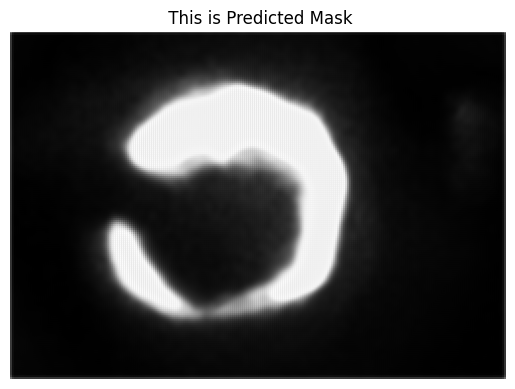

In [ ]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():

    image, mask = train_dataset[0]

    input_image = torch.tensor(image).permute(2, 0, 1).float() / 255.0

    input_image = input_image.unsqueeze(0).to(device)

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.imshow(prediction, cmap='gray')

plt.title(" This is Predicted Mask")

plt.axis("off")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),

            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),

            nn.ReLU()
        )

    def forward(self, x):

        return self.conv(x)

In [ ]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down = DoubleConv(3, 64)

        self.pool = nn.MaxPool2d(2)

        self.middle = DoubleConv(64, 128)

        self.up = nn.ConvTranspose2d(128, 64, 2, stride=2)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):

        x1 = self.down(x)

        x2 = self.pool(x1)

        x3 = self.middle(x2)

        x4 = self.up(x3)

        output = self.final(x4)

        return output

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [ ]:
model = UNet().to(device)

In [ ]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import cv2
class PlumeDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = [
            file for file in os.listdir(image_dir)
            if file.endswith(".jpeg")
        ]

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(
            self.image_dir,
            self.images[index]
        )

        mask_name = self.images[index].replace(".jpeg", "_mask.png")

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = cv2.imread(img_path)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        return image, mask

In [ ]:
train_dataset = PlumeDataset(

    image_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/images",

    mask_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"
)

train_loader = DataLoader(

    train_dataset,

    batch_size=2,

    shuffle=True
)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

In [ ]:
for epoch in range(5):

    print(f"Epoch {epoch+1}")

    for images, masks in train_loader:

        images = images.permute(0, 3, 1, 2).float() / 255.0

        masks = masks.unsqueeze(1).float() / 255.0

        images = images.to(device)

        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print("Loss:", loss.item())

Epoch 1
Loss: 0.7083413600921631
Epoch 2
Loss: 0.6535038948059082
Epoch 3
Loss: 0.5286535024642944
Epoch 4
Loss: 0.5554121732711792
Epoch 5
Loss: 0.41239434480667114


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images"))

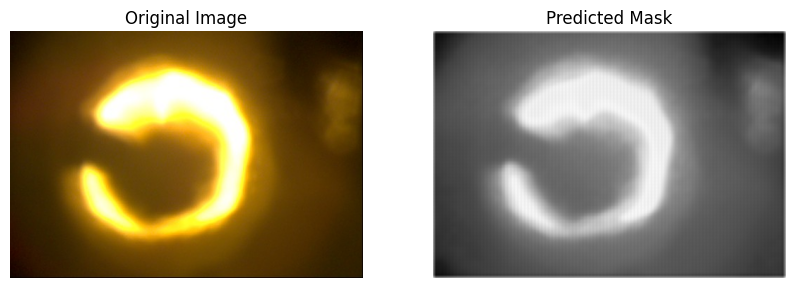

In [ ]:
test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/images/img1.jpeg"

image = cv2.imread(test_image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

input_image = torch.tensor(image_rgb).permute(2, 0, 1).float() / 255.0

input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image_rgb)

plt.title("Original Image")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(prediction, cmap='gray')

plt.title("Predicted Mask")

plt.axis("off")

plt.show()

In [4]:
import os
import json
import numpy as np
import cv2

json_folder = "/content/drive/MyDrive/PCI-PROJECT/annotations"
mask_folder = "/content/drive/MyDrive/PCI-PROJECT/masks"

os.makedirs(mask_folder, exist_ok=True)

json_files = [f for f in os.listdir(json_folder) if f.endswith(".json")]

for json_file in json_files:

    json_path = os.path.join(json_folder, json_file)

    with open(json_path, "r") as f:
        data = json.load(f)

    height = data["imageHeight"]
    width = data["imageWidth"]

    mask = np.zeros((height, width), dtype=np.uint8)

    for shape in data["shapes"]:

        points = np.array(shape["points"], dtype=np.int32)

        cv2.fillPoly(mask, [points], 255)

    mask_name = json_file.replace(".json", "_mask.png")

    mask_path = os.path.join(mask_folder, mask_name)

    cv2.imwrite(mask_path, mask)

print("All masks generated successfully!")

All masks generated successfully!


In [5]:
import os

mask_folder = "/content/drive/MyDrive/PCI-PROJECT/masks"

mask_files = [f for f in os.listdir(mask_folder) if f.endswith(".png")]

print("Total masks:", len(mask_files))

Total masks: 100


In [11]:
import os

folders = [
    "/content/drive/MyDrive/PCI-PROJECT/datasets/training/images",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/validation/images",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/validation/masks",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/masks"
]

for folder in folders:
    print(folder, "->", os.path.exists(folder))

/content/drive/MyDrive/PCI-PROJECT/datasets/training/images -> True
/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks -> True
/content/drive/MyDrive/PCI-PROJECT/datasets/validation/images -> True
/content/drive/MyDrive/PCI-PROJECT/datasets/validation/masks -> True
/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images -> True
/content/drive/MyDrive/PCI-PROJECT/datasets/testing/masks -> True


In [16]:
import os
import shutil
import random

image_folder = "/content/drive/MyDrive/PCI-PROJECT/images/PCI images"
mask_folder = "/content/drive/MyDrive/PCI-PROJECT/masks"

train_img = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/images"
train_mask = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"

val_img = "/content/drive/MyDrive/PCI-PROJECT/datasets/validation/images"
val_mask = "/content/drive/MyDrive/PCI-PROJECT/datasets/validation/masks"

test_img = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images"
test_mask = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/masks"

images = [f for f in os.listdir(image_folder) if f.endswith(".jpeg")]

# Shuffle
random.seed(42)
random.shuffle(images)

# Split
train_files = images[:70]
val_files = images[70:90]
test_files = images[90:100]

def copy_files(file_list, img_dest, mask_dest):

    for img_file in file_list:

        src_img = os.path.join(image_folder, img_file)

        mask_file = img_file.replace(".jpeg", "_mask.png")

        src_mask = os.path.join(mask_folder, mask_file)

        shutil.copy(src_img, os.path.join(img_dest, img_file))

        shutil.copy(src_mask, os.path.join(mask_dest, mask_file))

copy_files(train_files, train_img, train_mask)
copy_files(val_files, val_img, val_mask)
copy_files(test_files, test_img, test_mask)

print("Dataset split completed!")

Dataset split completed!


In [20]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)


cpu


In [27]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

In [28]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

In [29]:
model = UNet().to(device)

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  

In [30]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and Optimizer ready!")

Loss and Optimizer ready!


In [31]:
def validate(model, loader, criterion):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            total_loss += loss.item()

    return total_loss / len(loader)

In [33]:
for images, masks in train_loader:

    print(images.shape)
    print(masks.shape)

    break

torch.Size([4, 3, 350, 500])
torch.Size([4, 1, 350, 500])


In [34]:
class PlumeDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".jpeg")
        ])

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(self.image_dir, image_name)

        mask_name = image_name.replace(".jpeg", "_mask.png")

        mask_path = os.path.join(self.mask_dir, mask_name)

        # Read image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize both to 256x256
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256))

        # Convert to tensor
        image = torch.tensor(image).permute(2, 0, 1).float() / 255.0

        mask = torch.tensor(mask).unsqueeze(0).float() / 255.0

        return image, mask

In [35]:
train_dataset = PlumeDataset(
    "/content/drive/MyDrive/PCI-PROJECT/datasets/training/images",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"
)

val_dataset = PlumeDataset(
    "/content/drive/MyDrive/PCI-PROJECT/datasets/validation/images",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/validation/masks"
)

test_dataset = PlumeDataset(
    "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images",
    "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/masks"
)

In [36]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [37]:
for images, masks in train_loader:

    print(images.shape)

    print(masks.shape)

    break

torch.Size([4, 3, 256, 256])
torch.Size([4, 1, 256, 256])


In [38]:
model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model Ready!")

Model Ready!


In [39]:
def validate(model, loader, criterion):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            total_loss += loss.item()

    return total_loss / len(loader)

In [41]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    val_loss = validate(model, val_loader, criterion)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/5 | Train Loss: 0.1151 | Val Loss: 0.1207
Epoch 2/5 | Train Loss: 0.1161 | Val Loss: 0.1139
Epoch 3/5 | Train Loss: 0.1120 | Val Loss: 0.1046
Epoch 4/5 | Train Loss: 0.1089 | Val Loss: 0.0977
Epoch 5/5 | Train Loss: 0.1110 | Val Loss: 0.1029


In [42]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/PCI-PROJECT/models/unet_100images.pth"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [43]:
import os

test_folder = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images"

print(os.listdir(test_folder))

['img19.jpeg', 'img11.jpeg', 'img49.jpeg', 'img63.jpeg', 'img80.jpeg', 'img82.jpeg', 'img32.jpeg', 'img12.jpeg', 'img4.jpeg', 'img18.jpeg']


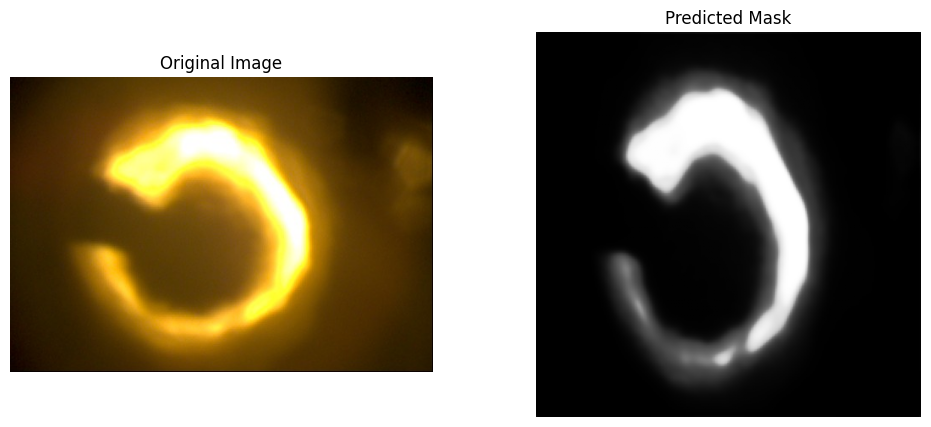

In [46]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images/img19.jpeg"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to same size used during training
image_resized = cv2.resize(image_rgb, (256, 256))

input_image = torch.tensor(image_resized).permute(2, 0, 1).float() / 255.0
input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

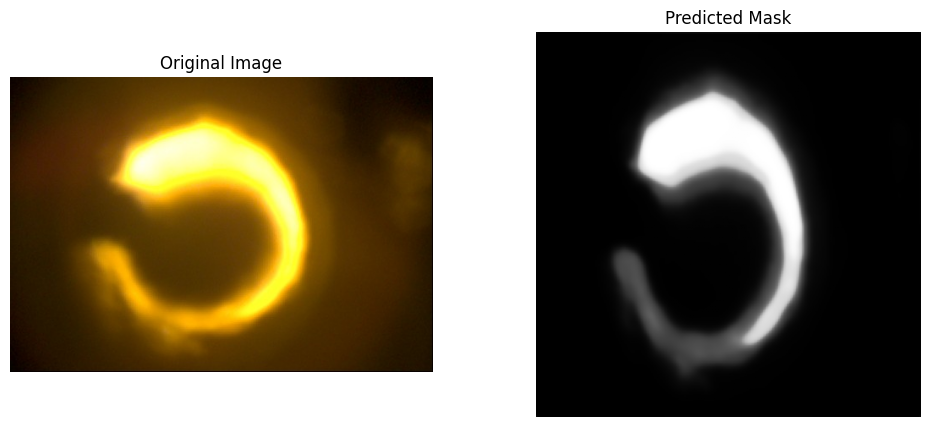

In [47]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images/img32.jpeg"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to same size used during training
image_resized = cv2.resize(image_rgb, (256, 256))

input_image = torch.tensor(image_resized).permute(2, 0, 1).float() / 255.0
input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

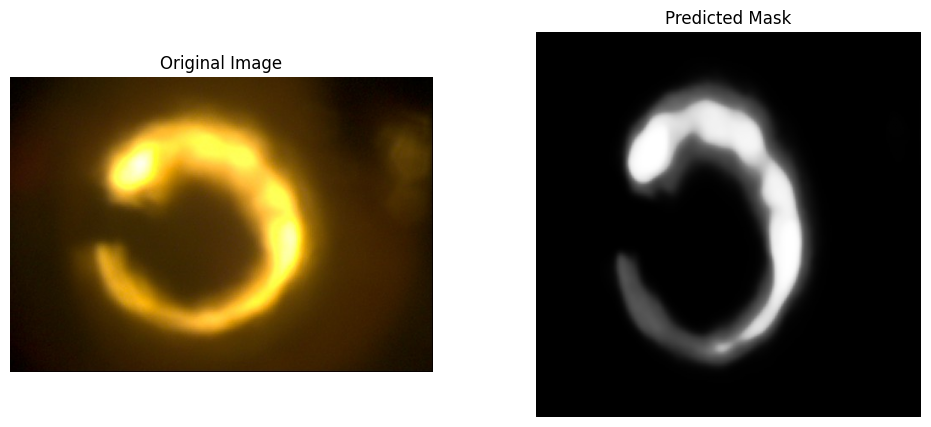

In [48]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images/img11.jpeg"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to same size used during training
image_resized = cv2.resize(image_rgb, (256, 256))

input_image = torch.tensor(image_resized).permute(2, 0, 1).float() / 255.0
input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

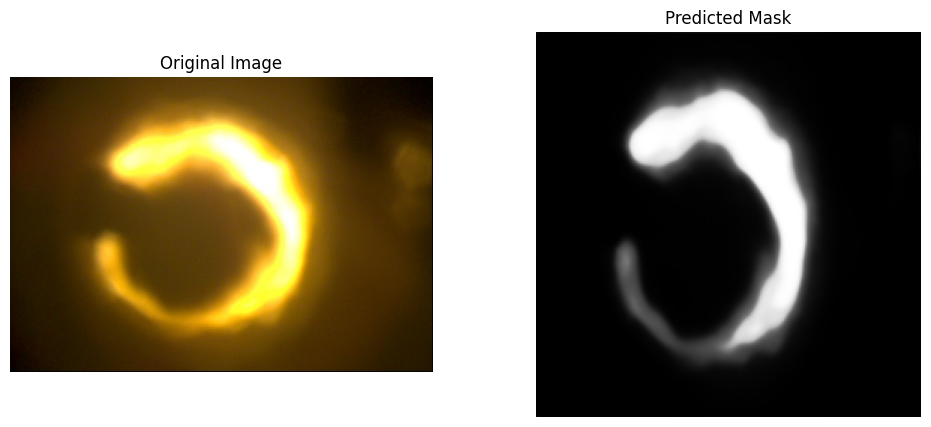

In [49]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images/img49.jpeg"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to same size used during training
image_resized = cv2.resize(image_rgb, (256, 256))

input_image = torch.tensor(image_resized).permute(2, 0, 1).float() / 255.0
input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

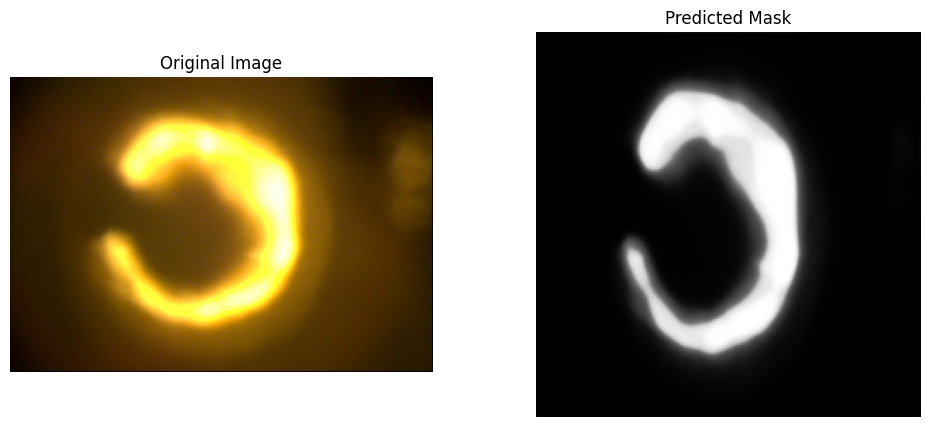

In [50]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images/img63.jpeg"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to same size used during training
image_resized = cv2.resize(image_rgb, (256, 256))

input_image = torch.tensor(image_resized).permute(2, 0, 1).float() / 255.0
input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

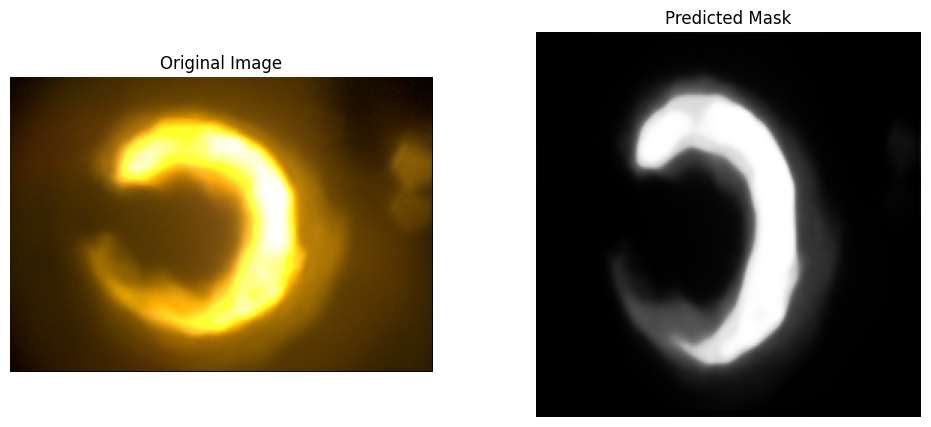

In [51]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images/img18.jpeg"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to same size used during training
image_resized = cv2.resize(image_rgb, (256, 256))

input_image = torch.tensor(image_resized).permute(2, 0, 1).float() / 255.0
input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

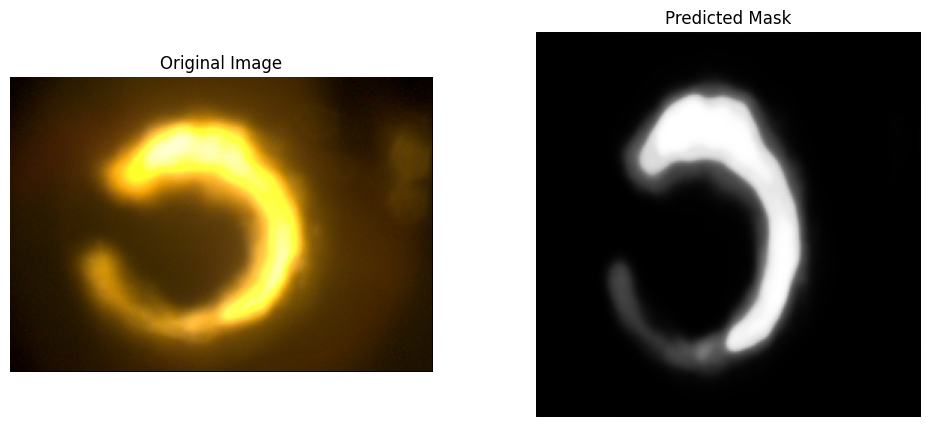

In [52]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_image_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/testing/images/img12.jpeg"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to same size used during training
image_resized = cv2.resize(image_rgb, (256, 256))

input_image = torch.tensor(image_resized).permute(2, 0, 1).float() / 255.0
input_image = input_image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    prediction = model(input_image)

    prediction = torch.sigmoid(prediction)

    prediction = prediction.squeeze().cpu().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()